In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import json
import numpy as np
import networkx as nx
import re
from pathlib import Path


# Colors
#COLOR = get_colors("palette")

### Intro simdata

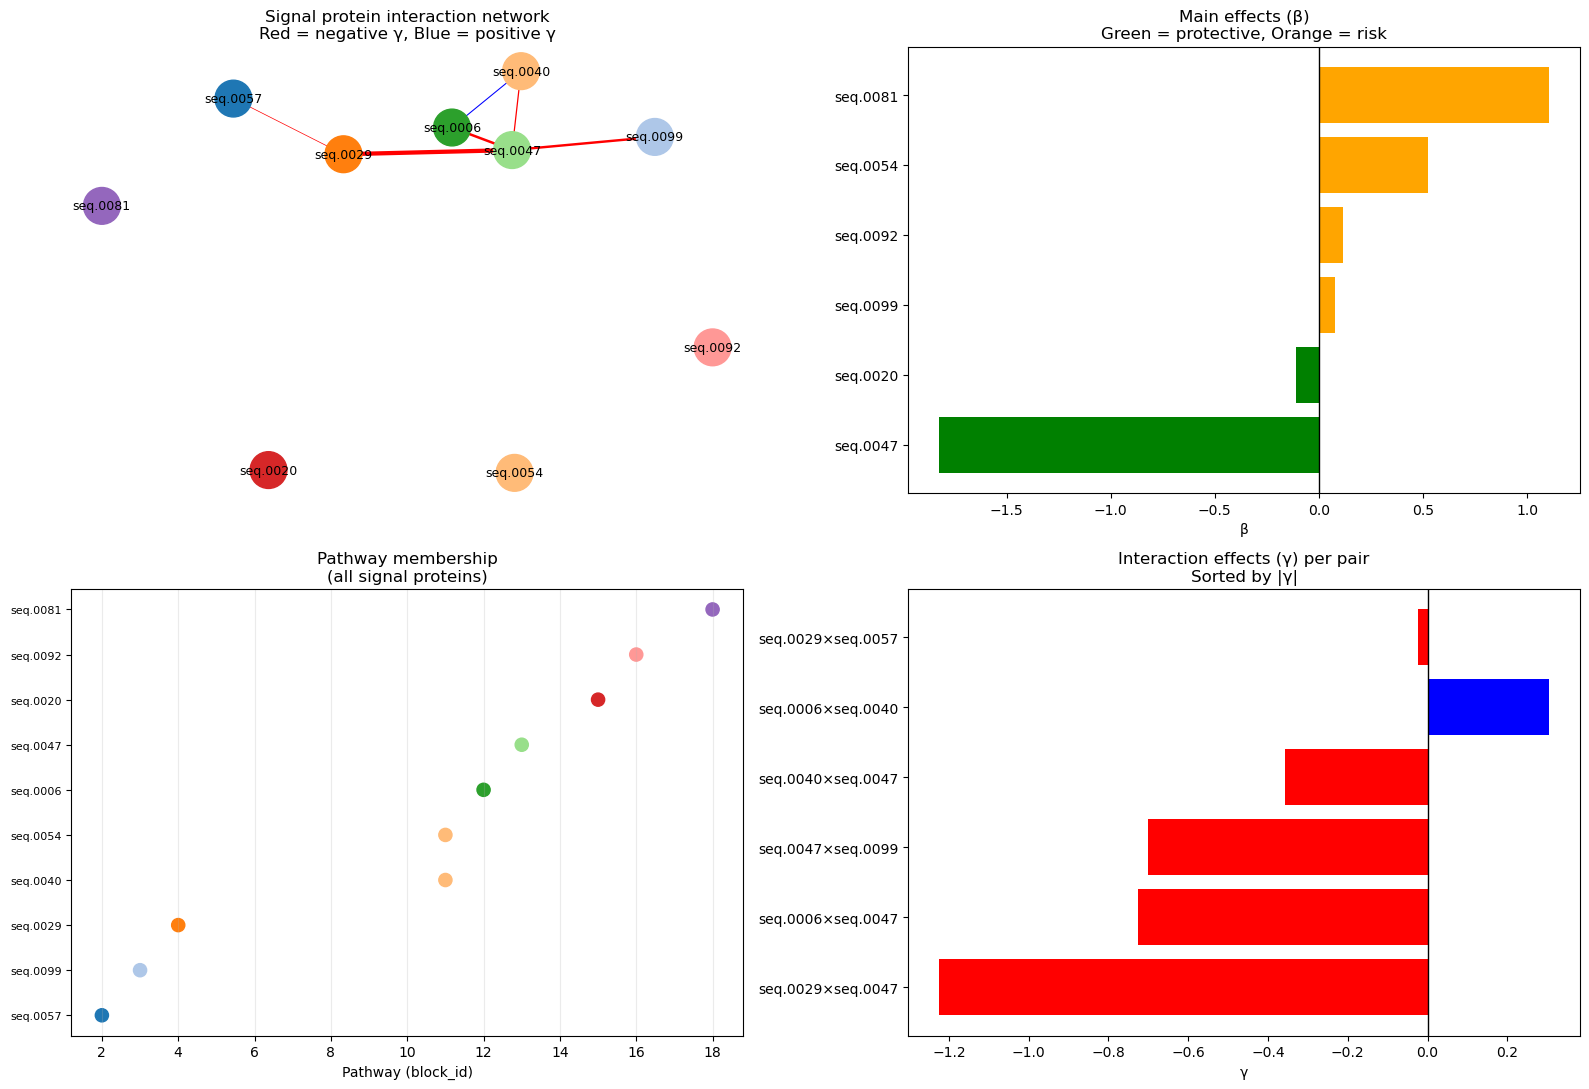

In [35]:
# =========================
# Data
# =========================
with open("../data/simulated/sim1/sim1_truth.json", "r", encoding="utf-8") as f:
    truth = json.load(f)

block_id = np.array(truth["block_id"], dtype=int)

signal_idx = list(truth["signal_idx"])          # alla signalproteiner
main_idx   = list(truth["main_idx"])            # main (inkl both)
inter_pairs = [tuple(x) for x in truth["interaction_pairs"]]

beta_vec  = np.array(truth["beta_vec"], dtype=float)   # matchar main_idx ordning
gamma_vec = np.array(truth["gamma_vec"], dtype=float)  # matchar inter_pairs ordning

# =========================
# Create network (signal-only nodes)
# =========================
G = nx.Graph()

for idx in signal_idx:
    G.add_node(idx, pathway=int(block_id[idx]))

signal_set = set(signal_idx)
for (u, v), gamma in zip(inter_pairs, gamma_vec):
    if (u in signal_set) and (v in signal_set):
        G.add_edge(u, v, gamma=float(gamma))

pos = nx.spring_layout(
    G,
    seed=2,
    k=2.2,          # större = mer utspritt
    iterations=200, # stabilare layout
    scale=3         # fyller ut figuren bättre
)

# =========================
# Color mapping by pathway
# =========================
pathways = [G.nodes[n]["pathway"] for n in G.nodes]
unique_paths = sorted(set(pathways))

cmap = plt.cm.tab20
color_map = {p: cmap((i % 20) / 20) for i, p in enumerate(unique_paths)}
node_colors = [color_map[G.nodes[n]["pathway"]] for n in G.nodes]

# =========================
# Plot: 2x2 subplots
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
ax_net, ax_beta, ax_path, ax_gamma = axes.flatten()

# ---- (1) Interaction Network (KEEP labels, NO pathway legend) ----
edges = list(G.edges(data=True))
edge_colors = ["red" if d["gamma"] < 0 else "blue" for (_, _, d) in edges]
edge_widths = [max(0.5, abs(d["gamma"]) * 2.5) for (_, _, d) in edges]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, ax=ax_net)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, ax=ax_net)

# keep labels
nx.draw_networkx_labels(
    G, pos,
    labels={n: f"seq.{n:04d}" for n in G.nodes},
    font_size=9,  # höj/sänk vid behov
    ax=ax_net
)

ax_net.set_title("Signal protein interaction network\nRed = negative γ, Blue = positive γ")
ax_net.axis("off")

# ---- (2) Main Effects (β) ----
beta_names = [f"seq.{idx:04d}" for idx in main_idx]

order = np.argsort(beta_vec)  # sort by beta
beta_sorted = beta_vec[order]
names_sorted = [beta_names[i] for i in order]

colors = ["green" if b < 0 else "orange" for b in beta_sorted]

ax_beta.barh(names_sorted, beta_sorted, color=colors)
ax_beta.axvline(0, color="black", linewidth=1)
ax_beta.set_title("Main effects (β)\nGreen = protective, Orange = risk")
ax_beta.set_xlabel("β")
ax_beta.set_ylabel("")

# ---- (3) Pathway membership for ALL signal proteins ----
sig_names = [f"seq.{idx:04d}" for idx in signal_idx]
sig_paths = [int(block_id[idx]) for idx in signal_idx]

order = np.lexsort((np.array(signal_idx), np.array(sig_paths)))  # sort by pathway then id
sig_names_sorted = [sig_names[i] for i in order]
sig_paths_sorted = [sig_paths[i] for i in order]

y = np.arange(len(sig_names_sorted))
x = sig_paths_sorted
c = [color_map[p] for p in sig_paths_sorted]

ax_path.scatter(x, y, s=90, c=c)
ax_path.set_yticks(y)
ax_path.set_yticklabels(sig_names_sorted, fontsize=8)
ax_path.set_xlabel("Pathway (block_id)")
ax_path.set_title("Pathway membership\n(all signal proteins)")
ax_path.grid(axis="x", alpha=0.25)

# ---- (4) Gamma per interaction pair ----
# Use original truth pairs + names (so you see all pairs even if they include non-signal endpoints)
pair_names = []
if "interaction_pair_names" in truth:
    pair_names = [f"{a}×{b}" for a, b in truth["interaction_pair_names"]]
else:
    pair_names = [f"seq.{u:04d}×seq.{v:04d}" for (u, v) in inter_pairs]

# Sort by absolute gamma (strongest on top)
order = np.argsort(np.abs(gamma_vec))[::-1]
gamma_sorted = gamma_vec[order]
pair_sorted = [pair_names[i] for i in order]

gcolors = ["red" if g < 0 else "blue" for g in gamma_sorted]

ax_gamma.barh(pair_sorted, gamma_sorted, color=gcolors)
ax_gamma.axvline(0, color="black", linewidth=1)
ax_gamma.set_title("Interaction effects (γ) per pair\nSorted by |γ|")
ax_gamma.set_xlabel("γ")
ax_gamma.set_ylabel("")

plt.tight_layout()
plt.show()


=== t-test (top 20) ===
Category counts: {'non-signal': 14, 'main': 2, 'interaction': 3, 'both': 1}
Selected features in signal-pathways: 17/20
Unique pathways (selected): [4, 7, 8, 11, 12, 13, 15, 18]
  Overlap with signal-pathways: [4, 11, 12, 13, 15, 18]
  Non-signal pathways present: [7, 8]

=== MI univariate (top 20) ===
Category counts: {'non-signal': 17, 'main': 1, 'interaction': 1, 'both': 1}
Selected features in signal-pathways: 12/20
Unique pathways (selected): [1, 4, 5, 6, 7, 10, 12, 13, 15, 16, 17, 18]
  Overlap with signal-pathways: [4, 12, 13, 15, 16, 18]
  Non-signal pathways present: [1, 5, 6, 7, 10, 17]

=== FS (top 20) ===
Category counts: {'non-signal': 16, 'main': 1, 'interaction': 2, 'both': 1}
Selected features in signal-pathways: 10/20
Unique pathways (selected): [0, 1, 2, 4, 5, 6, 8, 10, 11, 12, 13, 14, 17, 18]
  Overlap with signal-pathways: [2, 4, 11, 12, 13, 18]
  Non-signal pathways present: [0, 1, 5, 6, 8, 10, 14, 17]


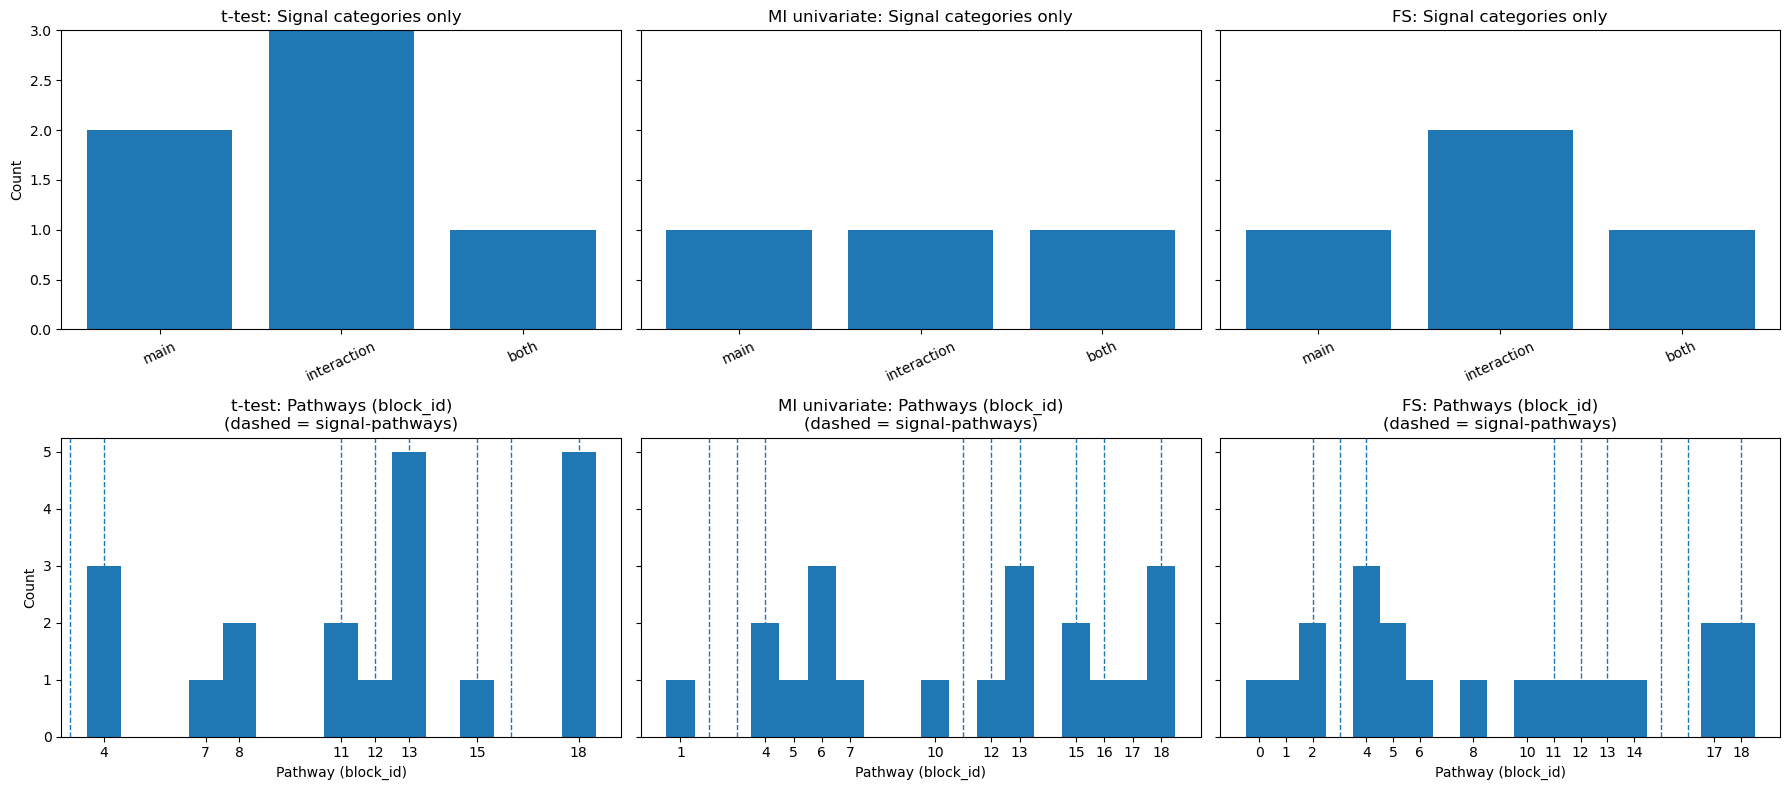

In [36]:

# -------------------------
# Load
# -------------------------
simdata = pd.read_csv("../data/simulated/sim1/sim1.csv")
features_ttest  = pd.read_csv("../results/sim_ttest/sim1/selected_features_k20.csv")
features_mi_uni = pd.read_csv("../results/sim_uni/sim1/selected_features_k20.csv")
features_fs     = pd.read_csv("../results/sim_fs/sim1/selected_features_n_features20.csv")

with open("../data/simulated/sim1/sim1_truth.json", "r", encoding="utf-8") as f:
    truth = json.load(f)

block_id = np.array(truth["block_id"], dtype=int)

signal_set = set(truth["signal_proteins"])
main_set   = set(truth["main_idx"])
inter_set  = set(truth["inter_idx"])
both_set   = set(truth["both_idx"])

signal_pathways = sorted({int(block_id[i]) for i in truth["signal_idx"]})

# -------------------------
# Helpers
# -------------------------
def _find_feature_col(df: pd.DataFrame) -> str:
    for c in ["Protein", "protein", "Feature", "feature", "features", "selected_feature"]:
        if c in df.columns:
            return c
    return df.columns[0]

def _to_seq_name(x) -> str:
    s = str(x).strip()
    m = re.search(r"seq\.(\d{1,4})", s)
    if m:
        return f"seq.{int(m.group(1)):04d}"
    m2 = re.fullmatch(r"\d+", s)
    if m2:
        return f"seq.{int(s):04d}"
    return s

def _seq_to_idx(seq_name: str):
    m = re.fullmatch(r"seq\.(\d{4})", seq_name)
    return int(m.group(1)) if m else None

def annotate(feature_list, method):
    rows = []
    for feat in feature_list:
        seq = _to_seq_name(feat)
        idx = _seq_to_idx(seq)
        pathway = int(block_id[idx]) if idx is not None and idx < len(block_id) else np.nan

        is_signal = seq in signal_set

        # Truth category (based on idx membership in main/inter sets)
        cat = "non-signal"
        if idx is not None:
            in_main = idx in main_set
            in_inter = idx in inter_set
            if in_main and in_inter:
                cat = "both"
            elif in_main:
                cat = "main"
            elif in_inter:
                cat = "interaction"
            elif is_signal:
                cat = "signal-other"

        rows.append({
            "method": method,
            "feature": seq,
            "idx": idx,
            "pathway": pathway,
            "category": cat,
            "is_signal": is_signal,
            "is_signal_pathway": (pathway in signal_pathways) if not np.isnan(pathway) else False
        })
    return pd.DataFrame(rows)

# -------------------------
# Collect selections (top 20)
# -------------------------
sel_t = features_ttest[_find_feature_col(features_ttest)].tolist()[:20]
sel_m = features_mi_uni[_find_feature_col(features_mi_uni)].tolist()[:20]
sel_f = features_fs[_find_feature_col(features_fs)].tolist()[:20]

df_t = annotate(sel_t, "t-test")
df_m = annotate(sel_m, "MI univariate")
df_f = annotate(sel_f, "FS")
dfs = [df_t, df_m, df_f]

# -------------------------
# Print quick textual summaries
# -------------------------
for df in dfs:
    method = df["method"].iloc[0]
    cat_counts = df["category"].value_counts().reindex(["non-signal","main","interaction","both"], fill_value=0)
    n_signal_path = int(df["is_signal_pathway"].sum())
    unique_paths = sorted(df["pathway"].dropna().astype(int).unique().tolist())
    unique_signal_paths = sorted(set(unique_paths).intersection(signal_pathways))
    unique_non_signal_paths = sorted(set(unique_paths) - set(signal_pathways))

    print(f"\n=== {method} (top {len(df)}) ===")
    print("Category counts:", dict(cat_counts))
    print(f"Selected features in signal-pathways: {n_signal_path}/{len(df)}")
    print(f"Unique pathways (selected): {unique_paths}")
    print(f"  Overlap with signal-pathways: {unique_signal_paths}")
    print(f"  Non-signal pathways present: {unique_non_signal_paths}")

# -------------------------
# Plot: 2 rows x 3 cols
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey='row')

methods = ["t-test", "MI univariate", "FS"]
cat_order = ["non-signal", "main", "interaction", "both"]

for j, (df, mname) in enumerate(zip(dfs, methods)):
    # Row 1: category histogram (EXCLUDE non-signal)
    ax1 = axes[0, j]
    counts_all = df["category"].value_counts()
    signal_cats = ["main", "interaction", "both"]
    counts = counts_all.reindex(signal_cats, fill_value=0)
    ax1.bar(signal_cats, counts.values)
    ax1.set_title(f"{mname}: Signal categories only")
    ax1.tick_params(axis='x', rotation=25)
    ax1.set_ylim(0, max(counts.values) + 1)
    if j == 0:
        ax1.set_ylabel("Count")

    # Row 2: pathway histogram
    ax2 = axes[1, j]
    paths = df["pathway"].dropna().astype(int).values
    if len(paths) > 0:
        # bins centered on integers
        bins = np.arange(paths.min() - 0.5, paths.max() + 1.5, 1)
        ax2.hist(paths, bins=bins)
        ax2.set_xticks(sorted(np.unique(paths)))
    ax2.set_title(f"{mname}: Pathways (block_id)\n(dashed = signal-pathways)")
    ax2.set_xlabel("Pathway (block_id)")
    if j == 0:
        ax2.set_ylabel("Count")

    # mark signal-pathways as vertical dashed lines (only those in visible range)
    xmin, xmax = ax2.get_xlim()
    for sp in signal_pathways:
        if xmin <= sp <= xmax:
            ax2.axvline(sp, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

In [37]:
# --- protein columns (alla utom ards) ---
protein_cols = [c for c in simdata.columns if c != "ards"]

# --- truth sets ---
signal_proteins = set(truth["signal_proteins"])
signal_idx = truth["signal_idx"]
signal_pathways = set(np.array(truth["block_id"], dtype=int)[signal_idx].tolist())

block_id = np.array(truth["block_id"], dtype=int)
prot_to_idx = {f"seq.{i:04d}": i for i in range(len(block_id))}

def get_pathway(prot: str):
    i = prot_to_idx.get(prot, None)
    return int(block_id[i]) if i is not None else None

# --- selected sets (kolumnen "protein") ---
sel_t = set(features_ttest["protein"].astype(str))
sel_m = set(features_mi_uni["protein"].astype(str))
sel_f = set(features_fs["protein"].astype(str))

# --- ranking lists (antar att filerna redan är sorterade "bäst först") ---
rank_t = list(features_ttest["protein"].astype(str))
rank_m = list(features_mi_uni["protein"].astype(str))
rank_f = list(features_fs["protein"].astype(str))

rank_maps = {
    "t-test": {p: r+1 for r, p in enumerate(rank_t)},
    "MI":     {p: r+1 for r, p in enumerate(rank_m)},
    "FS":     {p: r+1 for r, p in enumerate(rank_f)},
}

/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_51993/242961301.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_box, labels=methods)


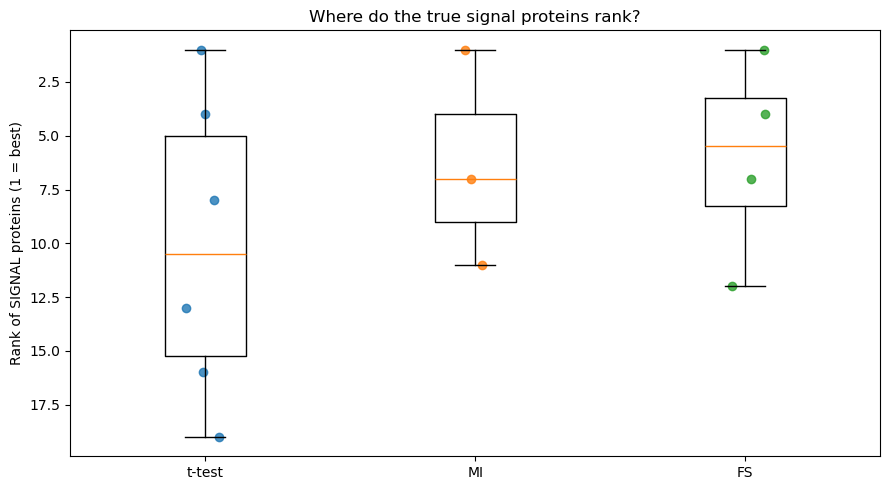

In [38]:
methods = ["t-test", "MI", "FS"]
sig_list = sorted(signal_proteins)

# ranks per method (NaN om proteinet saknas i listan av någon anledning)
rank_data = {}
for m in methods:
    rm = rank_maps[m]
    rank_data[m] = np.array([rm.get(p, np.nan) for p in sig_list], dtype=float)

fig, ax = plt.subplots(figsize=(9, 5))

data_for_box = [rank_data[m][~np.isnan(rank_data[m])] for m in methods]
ax.boxplot(data_for_box, labels=methods)

# scatter overlay (jitter)
for j, m in enumerate(methods, start=1):
    y = rank_data[m]
    y = y[~np.isnan(y)]
    x = j + (np.random.rand(len(y)) - 0.5) * 0.15
    ax.scatter(x, y, alpha=0.8)

ax.invert_yaxis()  # rank 1 (bäst) högst upp visuellt
ax.set_ylabel("Rank of SIGNAL proteins (1 = best)")
ax.set_title("Where do the true signal proteins rank?")
plt.tight_layout()
plt.show()

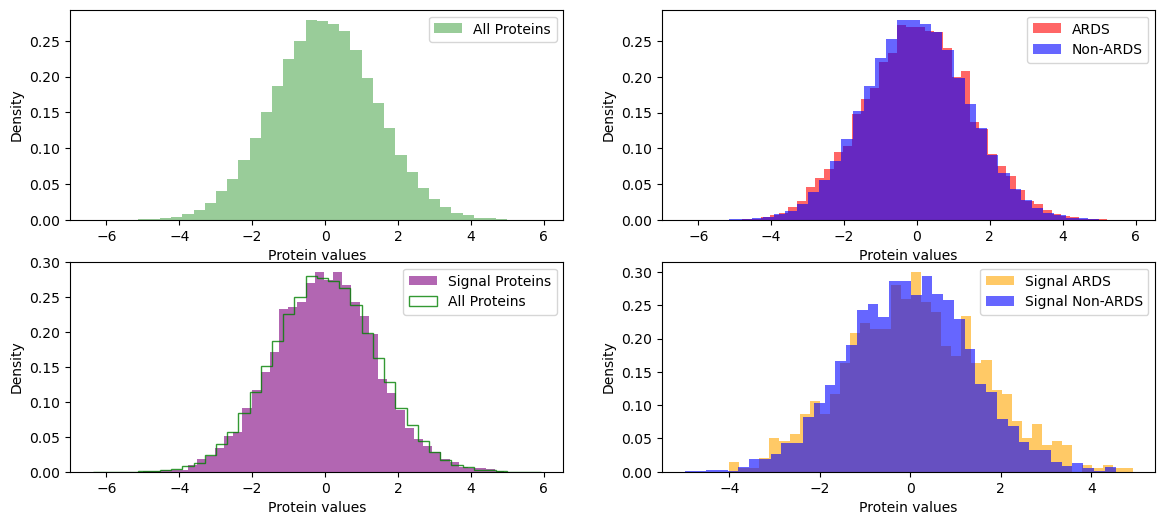

In [39]:
# Global distribution of protein values
protein_cols = [c for c in simdata.columns if c.startswith("seq")]

def extract_vals_by_group(df):
    protein_cols = [c for c in df.columns if c.startswith("seq")]

    vals_ards = df[df["ards"] == 1][protein_cols].values.ravel()
    vals_non = df[df["ards"] == 0][protein_cols].values.ravel()

    return vals_ards, vals_non


signal_proteins = truth["signal_proteins"]

# ARDS
signal_ards = (
    simdata.loc[simdata["ards"] == 1, signal_proteins]
    .values
    .ravel()
)

# Non-ARDS
signal_non = (
    simdata.loc[simdata["ards"] == 0, signal_proteins]
    .values
    .ravel()
)
signal_all = np.concatenate([signal_ards, signal_non])

ards_values = extract_vals_by_group(simdata)[0]
non_values = extract_vals_by_group(simdata)[1]
plt.figure(figsize=(14,6))
plt.subplot(2,2,1)
plt.hist(simdata[protein_cols].values.flatten(), bins=40, alpha=0.4, color= 'green',density=True, label="All Proteins")
plt.xlabel("Protein values")
plt.ylabel("Density")
plt.legend()
plt.subplot(2,2,2)
plt.hist(ards_values, bins=40, alpha=0.6, density=True, label="ARDS", color='red')
plt.hist(non_values, bins=40, alpha=0.6, density=True, label="Non-ARDS", color='blue')
plt.xlabel("Protein values")
plt.ylabel("Density")
plt.legend()
plt.subplot(2,2,3)
plt.hist(signal_all, bins=40, alpha=0.6, density=True, label="Signal Proteins", color='purple')
plt.hist(simdata[protein_cols].values.flatten(), bins=40, alpha=0.8, color= 'green',density=True, label="All Proteins", histtype='step')
plt.xlabel("Protein values")
plt.ylabel("Density")
plt.legend()
plt.subplot(2,2,4)
plt.hist(signal_ards, bins=40, alpha=0.6, density=True, label="Signal ARDS", color='orange')
plt.hist(signal_non, bins=40, alpha=0.6, density=True, label="Signal Non-ARDS", color='blue')
plt.xlabel("Protein values")
plt.ylabel("Density")
plt.legend()
plt.show()

### Univariate proteins

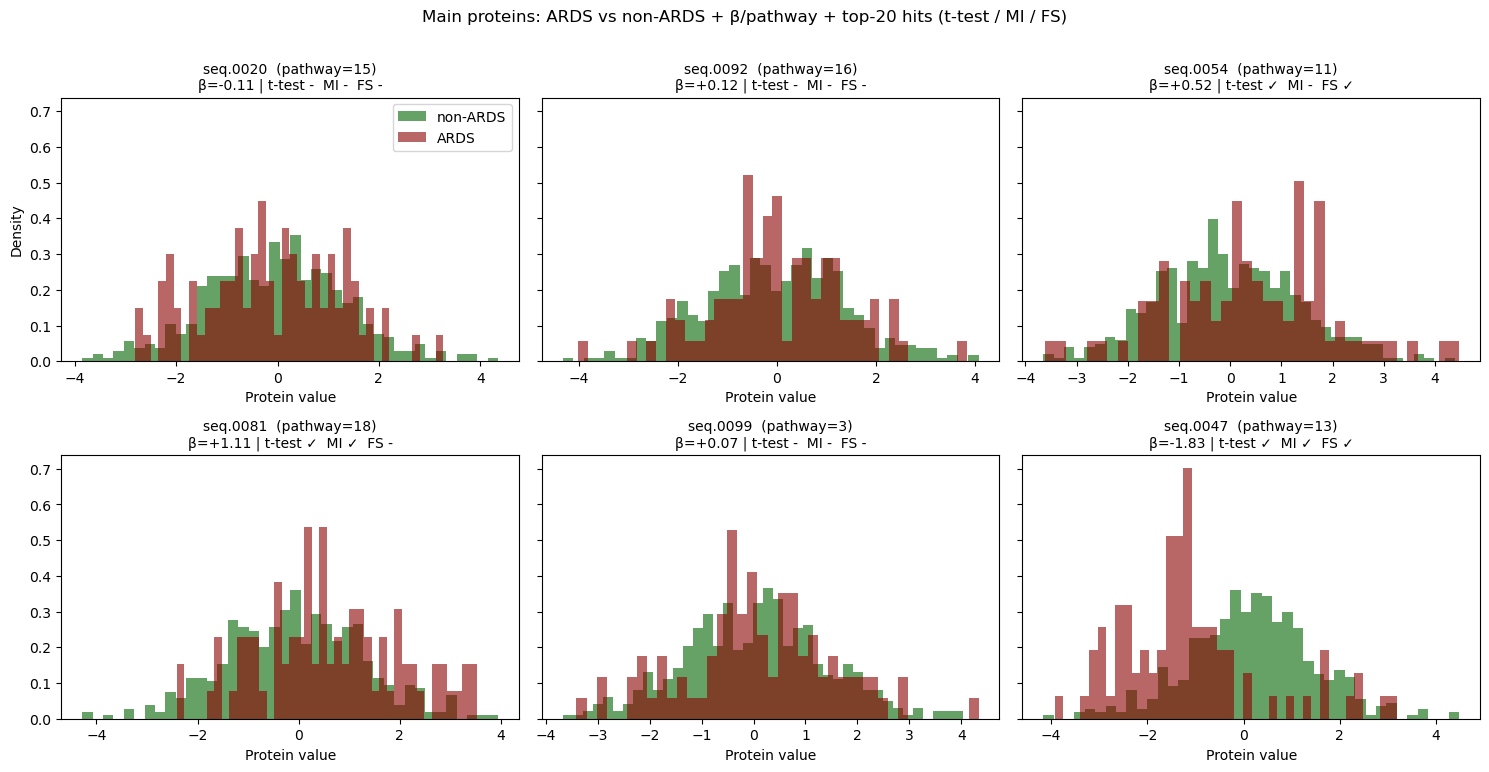

In [40]:
# Main signal proteins for ARDS vs Non-ARDS
with open("../data/simulated/sim1/sim1_truth.json", "r", encoding="utf-8") as f:
    truth = json.load(f)

main_idx = list(truth["main_idx"])                  # includes both
beta_vec = np.array(truth["beta_vec"], dtype=float) # aligned with main_idx
main_proteins = [f"seq.{idx:04d}" for idx in main_idx]

# -------------------------
# Helpers
# -------------------------
def _find_feature_col(df: pd.DataFrame) -> str:
    for c in ["protein", "Protein", "feature", "Feature", "selected_feature"]:
        if c in df.columns:
            return c
    return df.columns[0]

def _to_seq_name(x) -> str:
    s = str(x).strip()
    m = re.search(r"seq\.(\d{1,4})", s)
    if m:
        return f"seq.{int(m.group(1)):04d}"
    m2 = re.fullmatch(r"\d+", s)
    if m2:
        return f"seq.{int(s):04d}"
    return s

def make_selected_set(df: pd.DataFrame) -> set:
    col = _find_feature_col(df)
    return set(_to_seq_name(v) for v in df[col].astype(str).tolist())

sel_t = make_selected_set(features_ttest)
sel_m = make_selected_set(features_mi_uni)
sel_f = make_selected_set(features_fs)

def mark(found: bool) -> str:
    return "✓" if found else "-"

# -------------------------
# Plot settings
# -------------------------
n_show = len(main_proteins)
ncols = 3
nrows = int(np.ceil(n_show / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows), sharey=True)
axes = np.array(axes).ravel()

for i, ax in enumerate(axes):
    if i >= n_show:
        ax.axis("off")
        continue

    prot = main_proteins[i]
    idx = main_idx[i]
    beta = float(beta_vec[i])
    pathway = int(block_id[idx])

    non = simdata.loc[simdata["ards"] == 0, prot].values
    ards = simdata.loc[simdata["ards"] == 1, prot].values

    ax.hist(non, bins=40, alpha=0.6, density=True, color = "darkgreen", label="non-ARDS")
    ax.hist(ards, bins=40, alpha=0.6, density=True, color = "darkred", label="ARDS")

    # method hits
    hit_t = prot in sel_t
    hit_m = prot in sel_m
    hit_f = prot in sel_f

    hitline = f"t-test {mark(hit_t)}  MI {mark(hit_m)}  FS {mark(hit_f)}"

    ax.set_title(
        f"{prot}  (pathway={pathway})\nβ={beta:+.2f} | {hitline}",
        fontsize=10
    )
    ax.set_xlabel("Protein value")

axes[0].set_ylabel("Density")
axes[0].legend()

plt.suptitle("Main proteins: ARDS vs non-ARDS + β/pathway + top-20 hits (t-test / MI / FS)", y=1.01)
plt.tight_layout()
plt.show()

### Interaction pairs

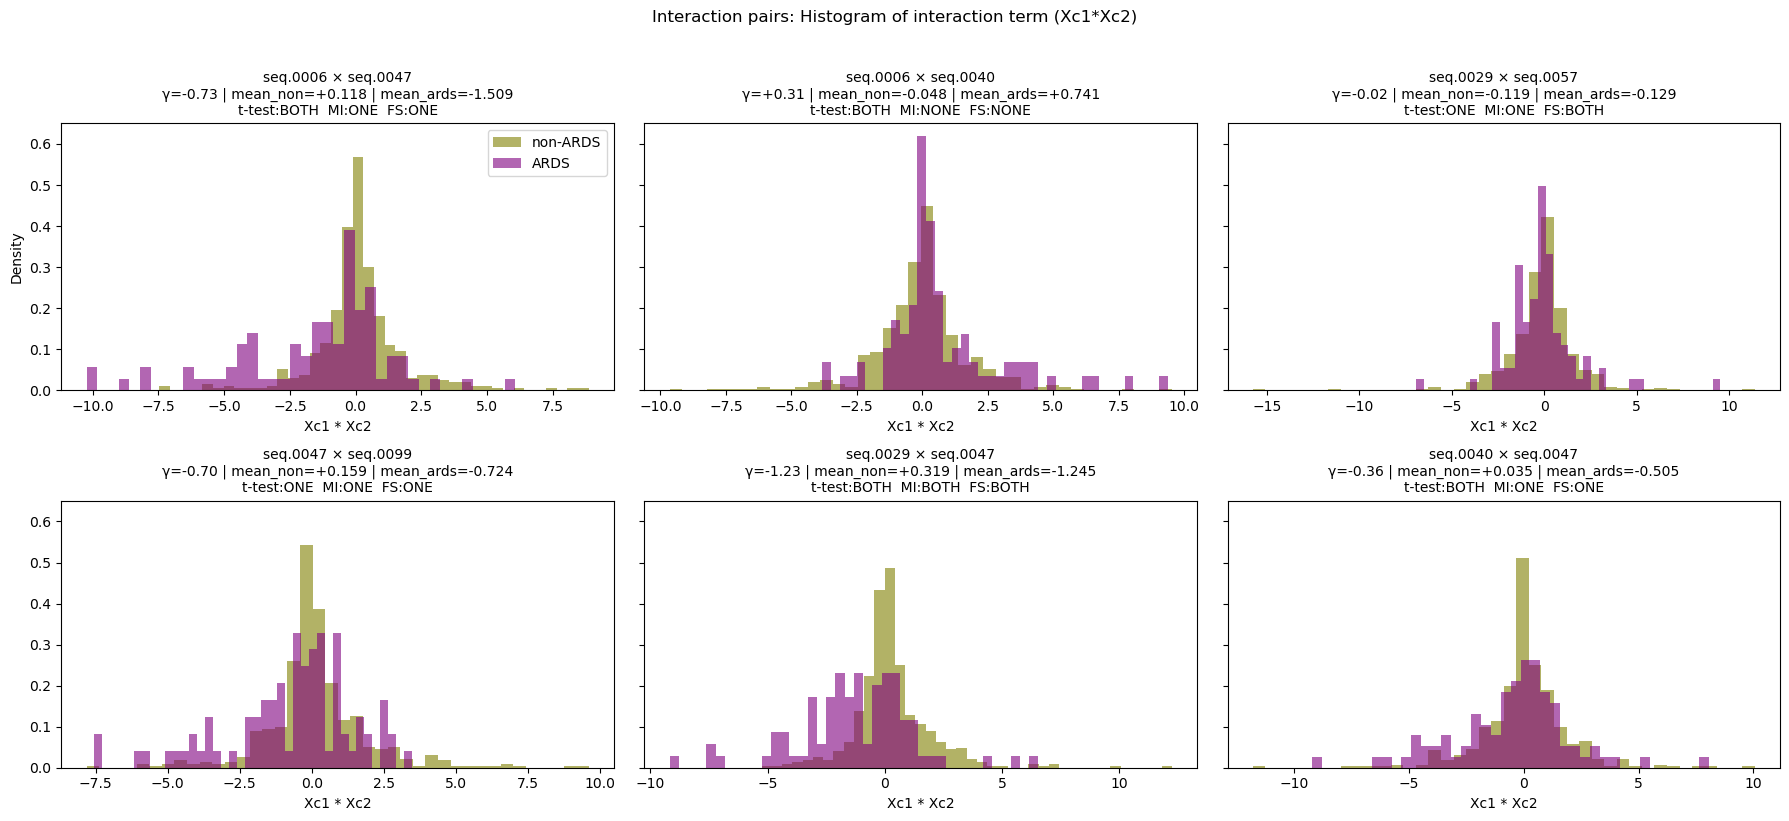

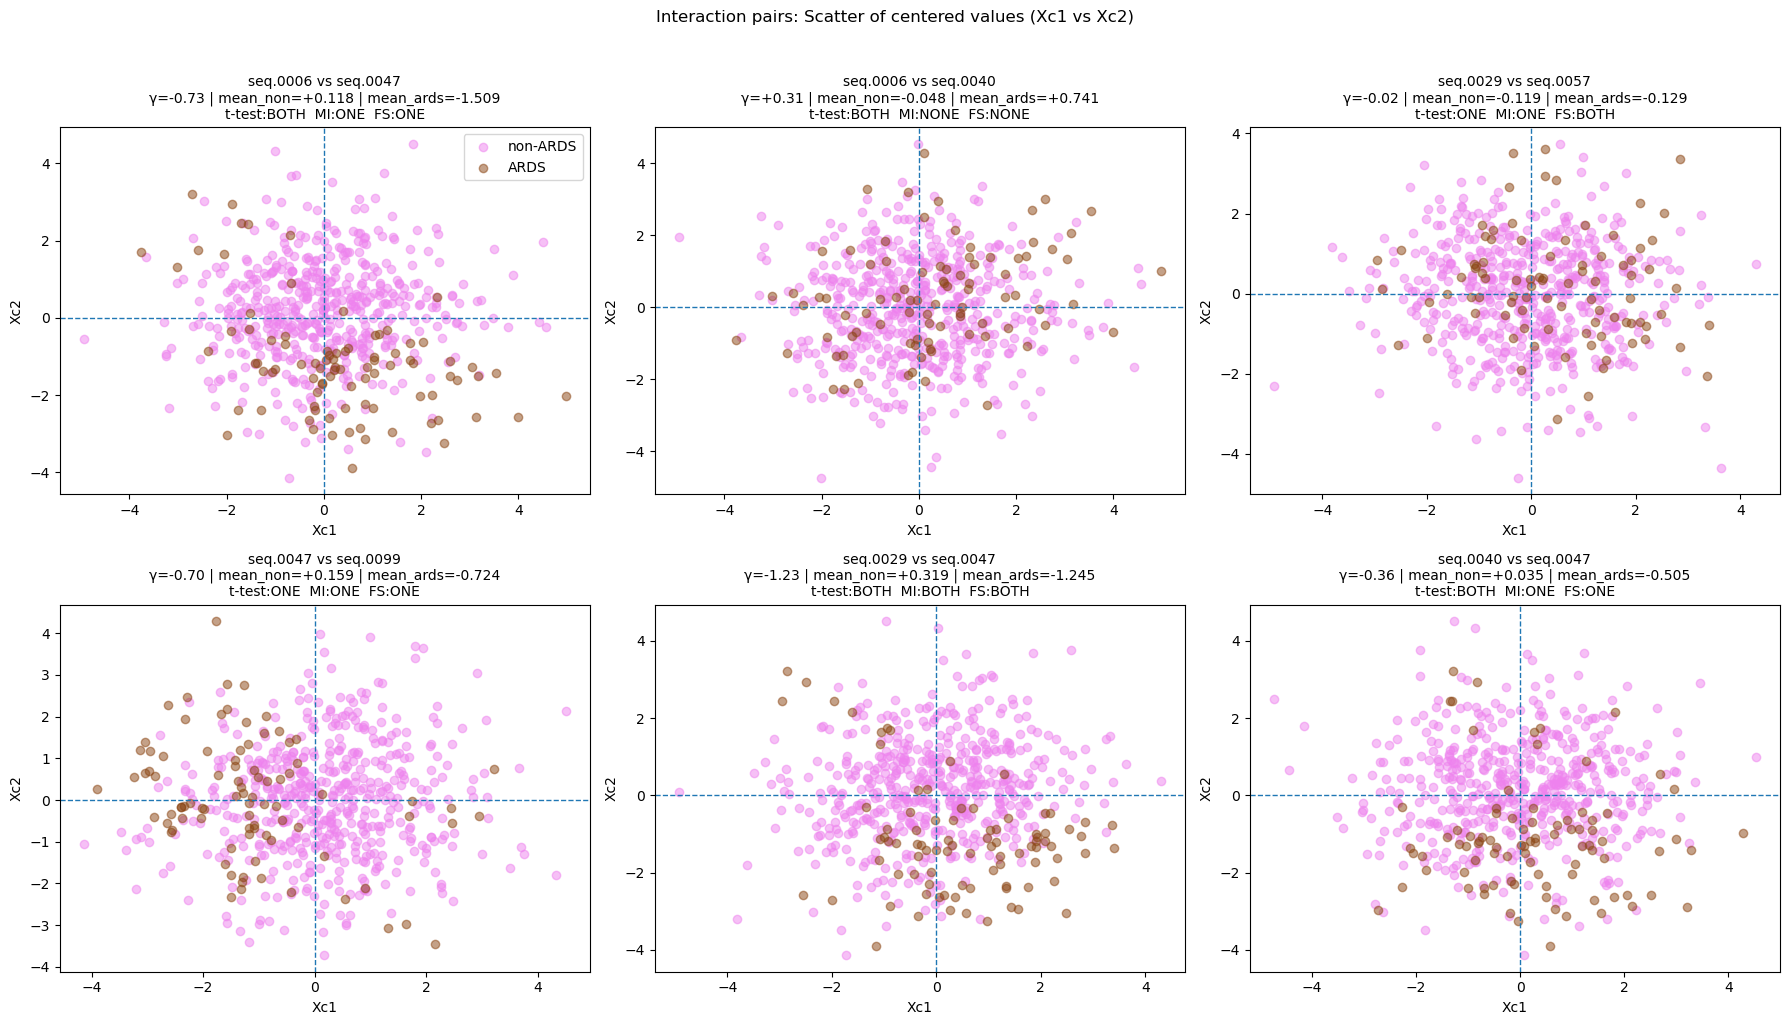

In [41]:
interaction_pairs = [tuple(p) for p in truth["interaction_pairs"]]
gamma_vec = np.array(truth["gamma_vec"], dtype=float)

# Selected sets (antar att dessa filer har kolumnen "protein" – annars byt här)
sel_t = set(features_ttest["protein"].astype(str))
sel_m = set(features_mi_uni["protein"].astype(str))
sel_f = set(features_fs["protein"].astype(str))

def pair_status(p1, p2, sel):
    a, b = (p1 in sel), (p2 in sel)
    return "BOTH" if (a and b) else ("ONE" if (a or b) else "NONE")

n_pairs = len(interaction_pairs)
ncols = 3
nrows = int(np.ceil(n_pairs / ncols))

# =========================
# HIST: Xc1*Xc2 (ARDS vs non)
# =========================
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
axes = np.array(axes).ravel()

for i, ax in enumerate(axes):
    if i >= n_pairs:
        ax.axis("off")
        continue

    idx1, idx2 = interaction_pairs[i]
    gamma = float(gamma_vec[i])

    p1 = f"seq.{idx1:04d}"
    p2 = f"seq.{idx2:04d}"

    x1c = simdata[p1] - simdata[p1].mean()
    x2c = simdata[p2] - simdata[p2].mean()
    inter_term = x1c * x2c

    mask = simdata["ards"] == 1
    term_non  = inter_term[~mask].values
    term_ards = inter_term[mask].values

    mean_non  = float(term_non.mean())
    mean_ards = float(term_ards.mean())

    st_t = pair_status(p1, p2, sel_t)
    st_m = pair_status(p1, p2, sel_m)
    st_f = pair_status(p1, p2, sel_f)

    ax.hist(term_non,  bins=40, density=True, alpha=0.6, color = "olive", label="non-ARDS")
    ax.hist(term_ards, bins=40, density=True, alpha=0.6, color = "purple", label="ARDS")

    ax.set_title(
        f"{p1} × {p2}\n"
        f"γ={gamma:+.2f} | mean_non={mean_non:+.3f} | mean_ards={mean_ards:+.3f}\n"
        f"t-test:{st_t}  MI:{st_m}  FS:{st_f}",
        fontsize=10
    )
    ax.set_xlabel("Xc1 * Xc2")

axes[0].set_ylabel("Density")
axes[0].legend()
plt.suptitle("Interaction pairs: Histogram of interaction term (Xc1*Xc2)", y=1.02)
plt.tight_layout()
plt.show()

# =========================
# SCATTER: Xc1 vs Xc2 (ARDS vs non)
# =========================
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = np.array(axes).ravel()

for i, ax in enumerate(axes):
    if i >= n_pairs:
        ax.axis("off")
        continue

    idx1, idx2 = interaction_pairs[i]
    gamma = float(gamma_vec[i])

    p1 = f"seq.{idx1:04d}"
    p2 = f"seq.{idx2:04d}"

    x1c = simdata[p1] - simdata[p1].mean()
    x2c = simdata[p2] - simdata[p2].mean()

    mask = simdata["ards"] == 1
    prod = x1c * x2c
    mean_non  = float(prod[~mask].mean())
    mean_ards = float(prod[mask].mean())

    st_t = pair_status(p1, p2, sel_t)
    st_m = pair_status(p1, p2, sel_m)
    st_f = pair_status(p1, p2, sel_f)

    ax.scatter(x1c[~mask], x2c[~mask], alpha=0.5, color = "violet", label="non-ARDS")
    ax.scatter(x1c[mask],  x2c[mask],  alpha=0.5, color = "saddlebrown", label="ARDS")

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axvline(0, linestyle="--", linewidth=1)

    ax.set_title(
        f"{p1} vs {p2}\n"
        f"γ={gamma:+.2f} | mean_non={mean_non:+.3f} | mean_ards={mean_ards:+.3f}\n"
        f"t-test:{st_t}  MI:{st_m}  FS:{st_f}",
        fontsize=10
    )
    ax.set_xlabel("Xc1")
    ax.set_ylabel("Xc2")

axes[0].legend()
plt.suptitle("Interaction pairs: Scatter of centered values (Xc1 vs Xc2)", y=1.02)
plt.tight_layout()
plt.show()

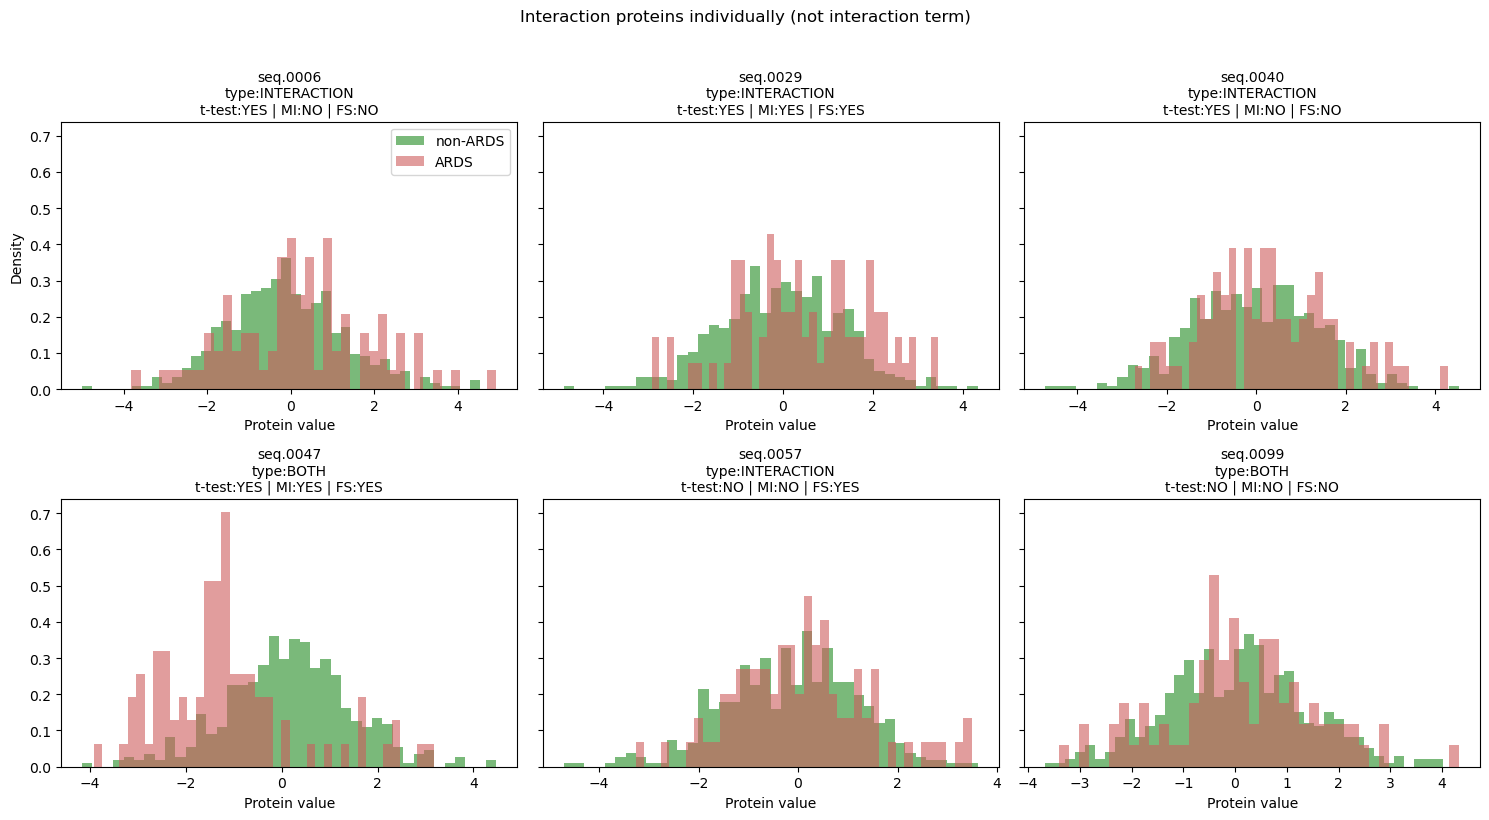

In [42]:
# gör även distribution för enskilda interaction protein såsom 06

# proteins involved in any interaction
inter_idx = sorted(set(sum(truth["interaction_pairs"], [])))
inter_proteins = [f"seq.{i:04d}" for i in inter_idx]

main_idx = set(truth["main_idx"])
inter_idx_set = set(truth["inter_idx"])

n = len(inter_proteins)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols,4*nrows), sharey=True)
axes = axes.ravel()

for i, ax in enumerate(axes):

    if i >= n:
        ax.axis("off")
        continue

    prot = inter_proteins[i]
    idx = int(prot.split(".")[1])

    # distributions
    non = simdata.loc[simdata["ards"]==0, prot]
    ards = simdata.loc[simdata["ards"]==1, prot]

    ax.hist(non, bins=40, density=True, alpha=0.6, color = "forestgreen", label="non-ARDS")
    ax.hist(ards, bins=40, density=True, alpha=0.6, color = "indianred", label="ARDS")

    # effect type
    if idx in main_idx and idx in inter_idx_set:
        effect_type = "BOTH"
    elif idx in main_idx:
        effect_type = "MAIN"
    elif idx in inter_idx_set:
        effect_type = "INTERACTION"
    else:
        effect_type = "NONE"

    # feature selection hits
    hit_t = prot in sel_t
    hit_m = prot in sel_m
    hit_f = prot in sel_f

    hitline = (
        f"t-test:{'YES' if hit_t else 'NO'} | "
        f"MI:{'YES' if hit_m else 'NO'} | "
        f"FS:{'YES' if hit_f else 'NO'}"
    )

    ax.set_title(
        f"{prot}\n"
        f"type:{effect_type}\n"
        f"{hitline}",
        fontsize=10
    )

    ax.set_xlabel("Protein value")

axes[0].set_ylabel("Density")
axes[0].legend()

plt.suptitle("Interaction proteins individually (not interaction term)", y=1.02)
plt.tight_layout()
plt.show()

# 6, 29 och 40 får egna postiva univariate effekt för att de har starka interaktionseffekter med protein 47 som är starkt negativt. 
# Iom att gamma då är negativt blir det större påverkan på ards om dom är positiva. 

In [43]:
# --- protein columns (alla utom ards) ---
protein_cols = [c for c in simdata.columns if c != "ards"]

# --- truth sets ---
signal_proteins = set(truth["signal_proteins"])
signal_idx = truth["signal_idx"]
signal_pathways = set(np.array(truth["block_id"], dtype=int)[signal_idx].tolist())

block_id = np.array(truth["block_id"], dtype=int)
prot_to_idx = {f"seq.{i:04d}": i for i in range(len(block_id))}

def get_pathway(prot: str):
    i = prot_to_idx.get(prot, None)
    return int(block_id[i]) if i is not None else None

# --- selected sets (kolumnen "protein") ---
sel_t = set(features_ttest["protein"].astype(str))
sel_m = set(features_mi_uni["protein"].astype(str))
sel_f = set(features_fs["protein"].astype(str))

# --- ranking lists (antar att filerna redan är sorterade "bäst först") ---
rank_t = list(features_ttest["protein"].astype(str))
rank_m = list(features_mi_uni["protein"].astype(str))
rank_f = list(features_fs["protein"].astype(str))

rank_maps = {
    "t-test": {p: r+1 for r, p in enumerate(rank_t)},
    "MI":     {p: r+1 for r, p in enumerate(rank_m)},
    "FS":     {p: r+1 for r, p in enumerate(rank_f)},
}

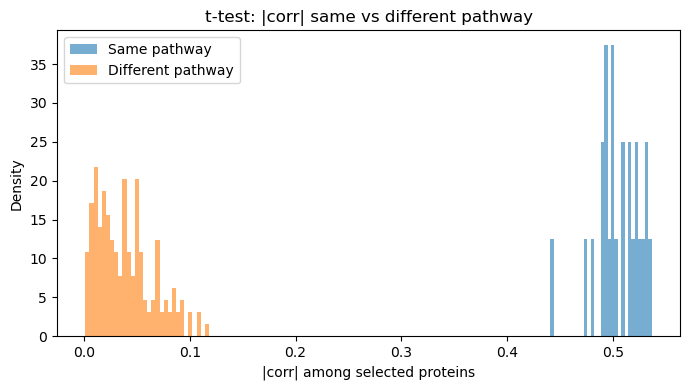

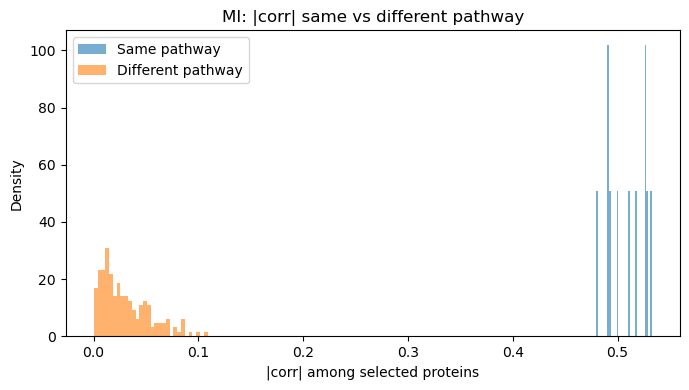

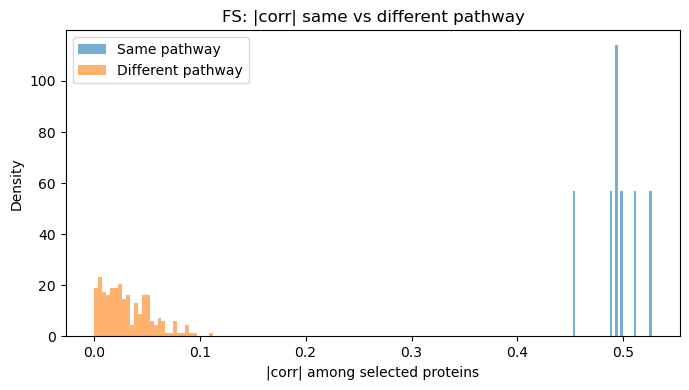

In [44]:
def corr_same_vs_diff(selected_list, title, k=20):
    feats = [p for p in selected_list if p in simdata.columns][:k]
    if len(feats) < 3:
        print(f"Too few features for {title}")
        return

    X = simdata[feats].to_numpy()
    C = np.corrcoef(X, rowvar=False)

    paths = [get_pathway(p) for p in feats]

    same_vals = []
    diff_vals = []

    for i in range(len(feats)):
        for j in range(i+1, len(feats)):
            if paths[i] is None or paths[j] is None:
                continue
            v = abs(C[i, j])
            if paths[i] == paths[j]:
                same_vals.append(v)
            else:
                diff_vals.append(v)

    same_vals = np.array(same_vals)
    diff_vals = np.array(diff_vals)

    fig, ax = plt.subplots(figsize=(7,4))
    bins = 30
    ax.hist(same_vals, bins=bins, alpha=0.6, density=True, label="Same pathway")
    ax.hist(diff_vals, bins=bins, alpha=0.6, density=True, label="Different pathway")
    ax.set_title(title)
    ax.set_xlabel("|corr| among selected proteins")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()

corr_same_vs_diff(rank_t, "t-test: |corr| same vs different pathway", k=20)
corr_same_vs_diff(rank_m, "MI: |corr| same vs different pathway", k=20)
corr_same_vs_diff(rank_f, "FS: |corr| same vs different pathway", k=20)

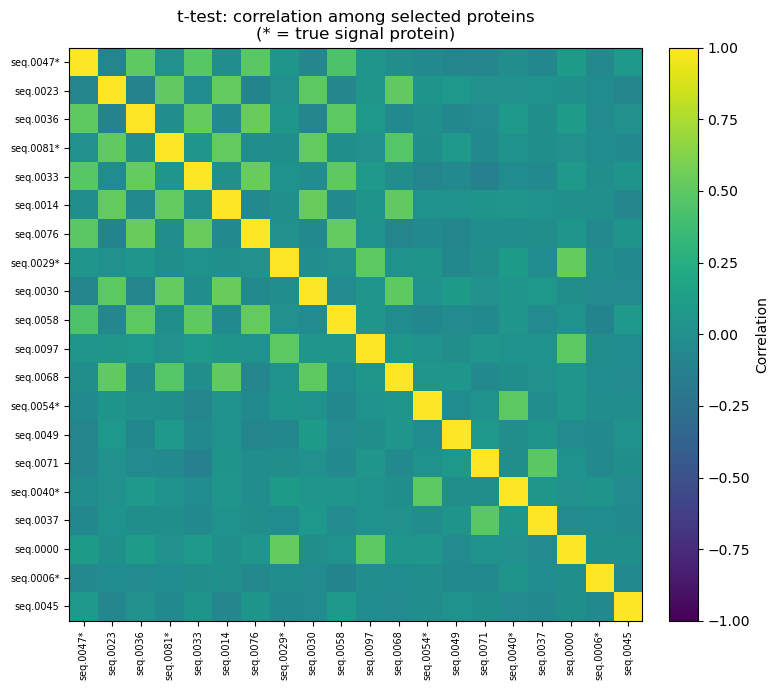

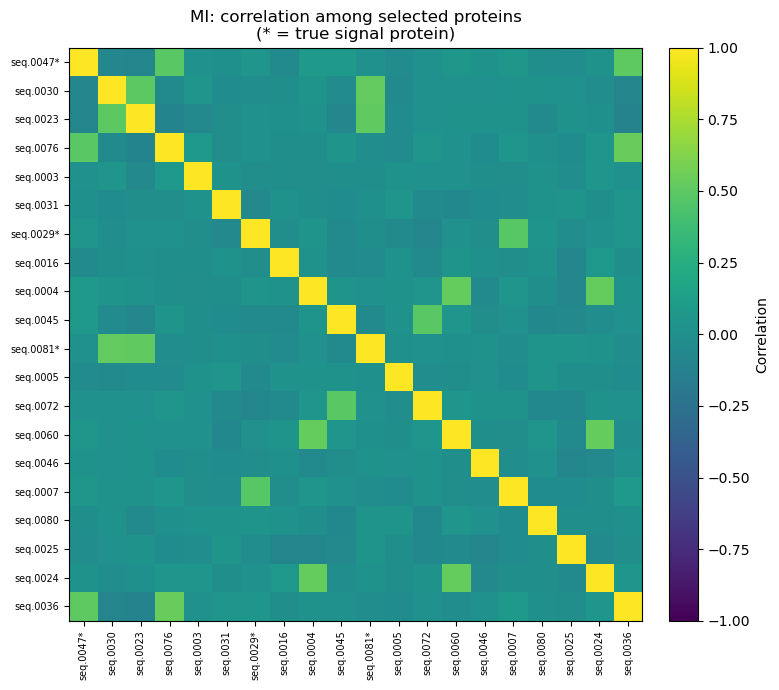

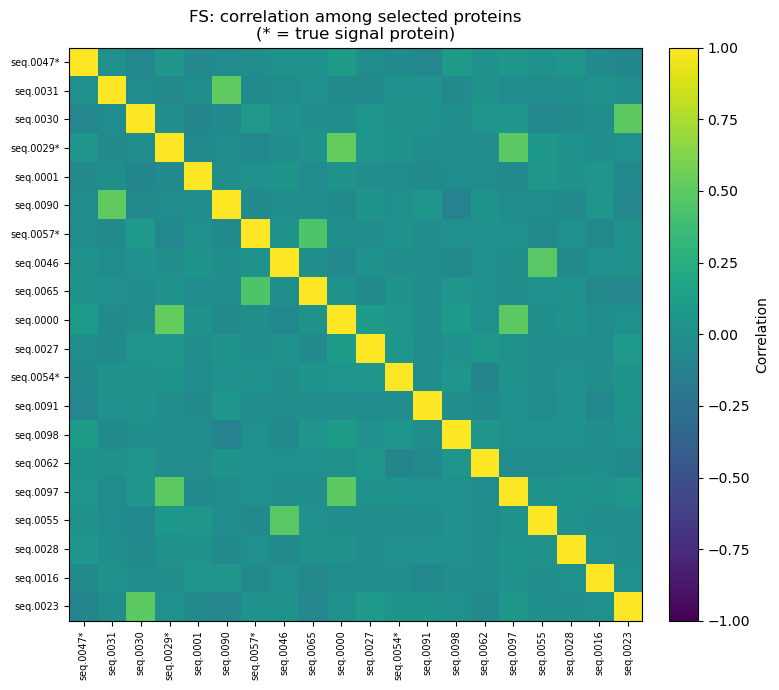

In [45]:
def corr_heatmap(data, truth, selected_list, title, k=20):

    signal_proteins = set(truth["signal_proteins"])

    feats = [p for p in selected_list if p in data.columns][:k]

    if len(feats) < 2:
        print(f"Too few features for {title}")
        return

    X = data[feats].to_numpy()
    C = np.corrcoef(X, rowvar=False)

    labels = [f"{p}*" if p in signal_proteins else p for p in feats]

    fig, ax = plt.subplots(figsize=(8,7))

    im = ax.imshow(C, vmin=-1, vmax=1)

    ax.set_title(title + "\n(* = true signal protein)")

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation")

    plt.tight_layout()
    plt.show()

corr_heatmap(simdata, truth, rank_t, "t-test: correlation among selected proteins", k=20)
corr_heatmap(simdata, truth, rank_m, "MI: correlation among selected proteins", k=20)
corr_heatmap(simdata, truth, rank_f, "FS: correlation among selected proteins", k=20)

# Simulation 2; 10 000 proteins

In [46]:
# -------------------------
# Paths
# -------------------------
sim2_dir = Path("../data/simulated/sim2")

simdata2_path = sim2_dir / "sim2.csv"
truth2_path = sim2_dir / "sim2_truth.json"

ttest2_path = Path("../results/sim_ttest/sim2/selected_features_k20.csv")
mi2_path    = Path("../results/sim_uni/sim2/selected_features_k20.csv")
fs2_path    = Path("../results/sim_fs/sim2/selected_features_n_features20.csv")

# -------------------------
# Load data
# -------------------------
simdata2 = pd.read_csv(simdata2_path)

with open(truth2_path, "r") as f:
    truth2 = json.load(f)

features_ttest2 = pd.read_csv(ttest2_path)
features_mi2    = pd.read_csv(mi2_path)
features_fs2    = pd.read_csv(fs2_path)

# -------------------------
# Ranking lists
# -------------------------
rank_t2 = features_ttest2["protein"].astype(str).tolist()
rank_m2 = features_mi2["protein"].astype(str).tolist()
rank_f2 = features_fs2["protein"].astype(str).tolist()


=== t-test (top 20) ===
Category counts: {'non-signal': 15, 'main': 1, 'interaction': 3, 'both': 1}
Selected features in signal-pathways: 20/20
Unique pathways (selected): [18]
  Overlap with signal-pathways: [18]
  Non-signal pathways present: []

=== MI univariate (top 20) ===
Category counts: {'non-signal': 20, 'main': 0, 'interaction': 0, 'both': 0}
Selected features in signal-pathways: 17/20
Unique pathways (selected): [0, 1, 2, 3, 4, 8, 9, 10, 11, 12, 13, 18, 19]
  Overlap with signal-pathways: [0, 1, 2, 3, 4, 8, 10, 11, 12, 13, 18, 19]
  Non-signal pathways present: [9]

=== FS (top 20) ===
Category counts: {'non-signal': 19, 'main': 0, 'interaction': 1, 'both': 0}
Selected features in signal-pathways: 20/20
Unique pathways (selected): [0, 2, 6, 11, 12, 13, 16, 17]
  Overlap with signal-pathways: [0, 2, 6, 11, 12, 13, 16, 17]
  Non-signal pathways present: []


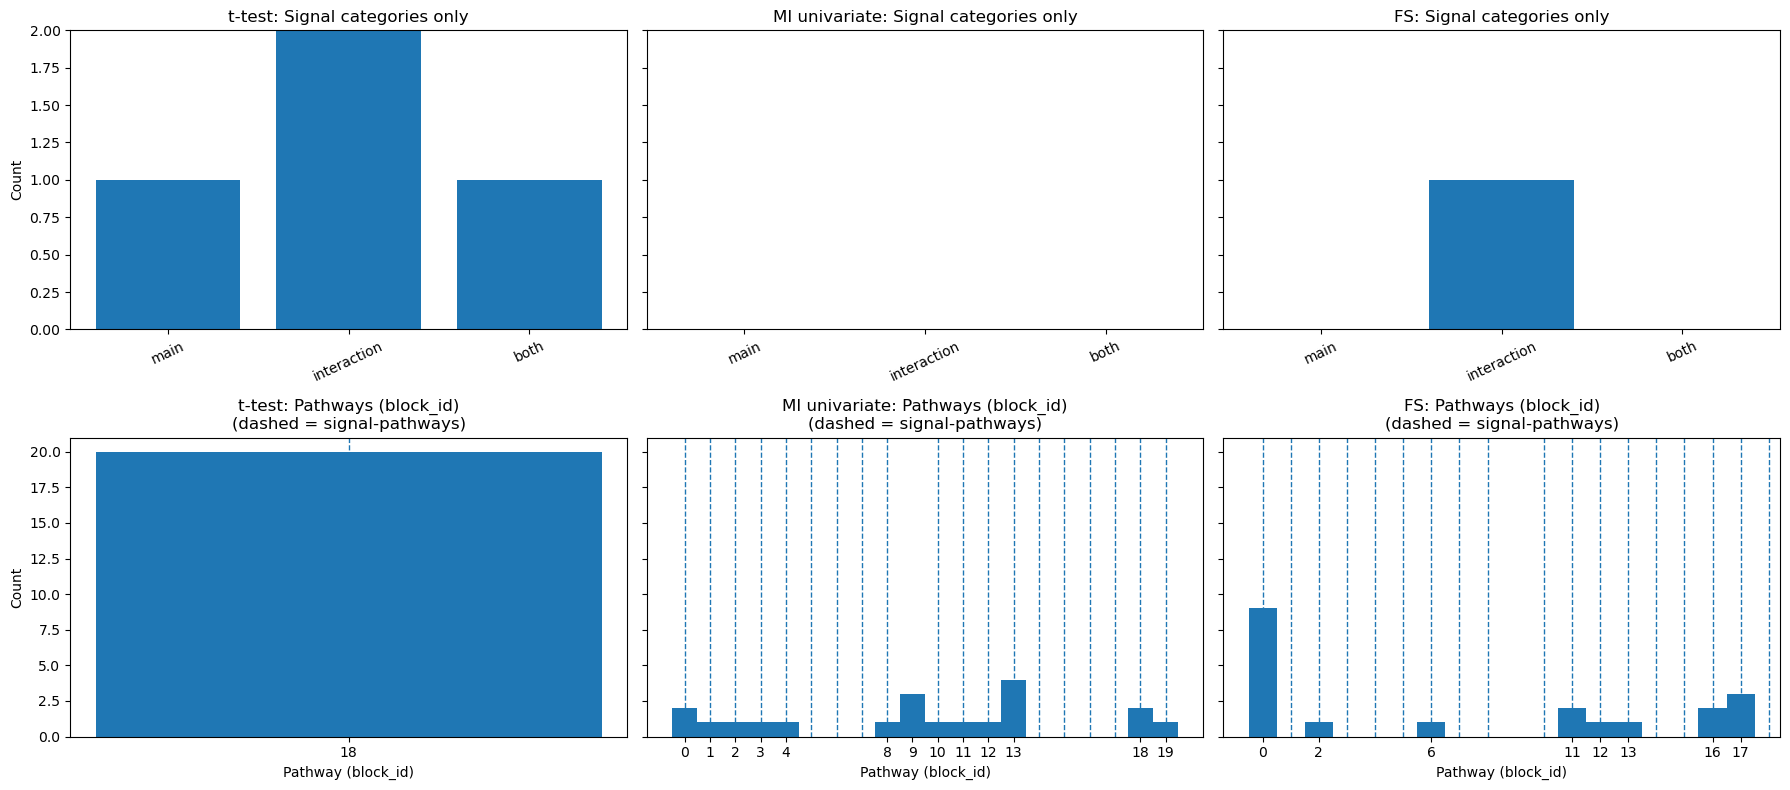

In [47]:
block_id2 = np.array(truth2["block_id"], dtype=int)

signal_set2 = set(truth2["signal_proteins"])
main_set2   = set(truth2["main_idx"])
inter_set2  = set(truth2["inter_idx"])
both_set2   = set(truth2["both_idx"])

signal_pathways2 = sorted({int(block_id2[i]) for i in truth2["signal_idx"]})

# -------------------------
# Helpers for sim2
# -------------------------
def annotate2(feature_list, method):
    rows = []
    for feat in feature_list:
        seq = _to_seq_name(feat)
        idx = _seq_to_idx(seq)
        pathway = int(block_id2[idx]) if idx is not None and idx < len(block_id2) else np.nan

        is_signal = seq in signal_set2

        cat = "non-signal"
        if idx is not None:
            in_main = idx in main_set2
            in_inter = idx in inter_set2
            if in_main and in_inter:
                cat = "both"
            elif in_main:
                cat = "main"
            elif in_inter:
                cat = "interaction"
            elif is_signal:
                cat = "signal-other"

        rows.append({
            "method": method,
            "feature": seq,
            "idx": idx,
            "pathway": pathway,
            "category": cat,
            "is_signal": is_signal,
            "is_signal_pathway": (pathway in signal_pathways2) if not np.isnan(pathway) else False
        })
    return pd.DataFrame(rows)

# -------------------------
# Collect selections (top 20) for sim2
# -------------------------
sel_t2 = features_ttest2[_find_feature_col(features_ttest2)].tolist()[:20]
sel_m2 = features_mi2[_find_feature_col(features_mi2)].tolist()[:20]
sel_f2 = features_fs2[_find_feature_col(features_fs2)].tolist()[:20]

df_t2 = annotate2(sel_t2, "t-test")
df_m2 = annotate2(sel_m2, "MI univariate")
df_f2 = annotate2(sel_f2, "FS")
dfs2 = [df_t2, df_m2, df_f2]

# -------------------------
# Print quick textual summaries for sim2
# -------------------------
for df in dfs2:
    method = df["method"].iloc[0]
    cat_counts = df["category"].value_counts().reindex(
        ["non-signal", "main", "interaction", "both"], fill_value=0
    )
    n_signal_path2 = int(df["is_signal_pathway"].sum())
    unique_paths2 = sorted(df["pathway"].dropna().astype(int).unique().tolist())
    unique_signal_paths2 = sorted(set(unique_paths2).intersection(signal_pathways2))
    unique_non_signal_paths2 = sorted(set(unique_paths2) - set(signal_pathways2))

    print(f"\n=== {method} (top {len(df)}) ===")
    print("Category counts:", dict(cat_counts))
    print(f"Selected features in signal-pathways: {n_signal_path2}/{len(df)}")
    print(f"Unique pathways (selected): {unique_paths2}")
    print(f"  Overlap with signal-pathways: {unique_signal_paths2}")
    print(f"  Non-signal pathways present: {unique_non_signal_paths2}")

# -------------------------
# Plot: 2 rows x 3 cols for sim2
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey="row")

methods2 = ["t-test", "MI univariate", "FS"]

for j, (df, mname) in enumerate(zip(dfs2, methods2)):
    # Row 1: category histogram (exclude non-signal)
    ax1 = axes[0, j]
    counts_all2 = df["category"].value_counts()
    signal_cats2 = ["main", "interaction", "both"]
    counts2 = counts_all2.reindex(signal_cats2, fill_value=0)

    ax1.bar(signal_cats2, counts2.values)
    ax1.set_title(f"{mname}: Signal categories only")
    ax1.tick_params(axis="x", rotation=25)
    ax1.set_ylim(0, max(counts2.values) + 1)
    if j == 0:
        ax1.set_ylabel("Count")

    # Row 2: pathway histogram
    ax2 = axes[1, j]
    paths2 = df["pathway"].dropna().astype(int).values
    if len(paths2) > 0:
        bins2 = np.arange(paths2.min() - 0.5, paths2.max() + 1.5, 1)
        ax2.hist(paths2, bins=bins2)
        ax2.set_xticks(sorted(np.unique(paths2)))

    ax2.set_title(f"{mname}: Pathways (block_id)\n(dashed = signal-pathways)")
    ax2.set_xlabel("Pathway (block_id)")
    if j == 0:
        ax2.set_ylabel("Count")

    xmin, xmax = ax2.get_xlim()
    for sp2 in signal_pathways2:
        if xmin <= sp2 <= xmax:
            ax2.axvline(sp2, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

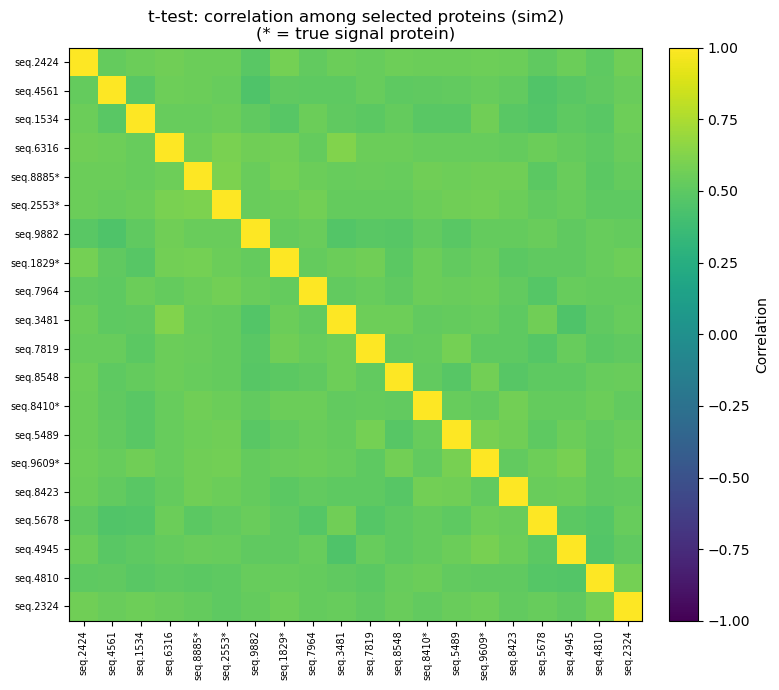

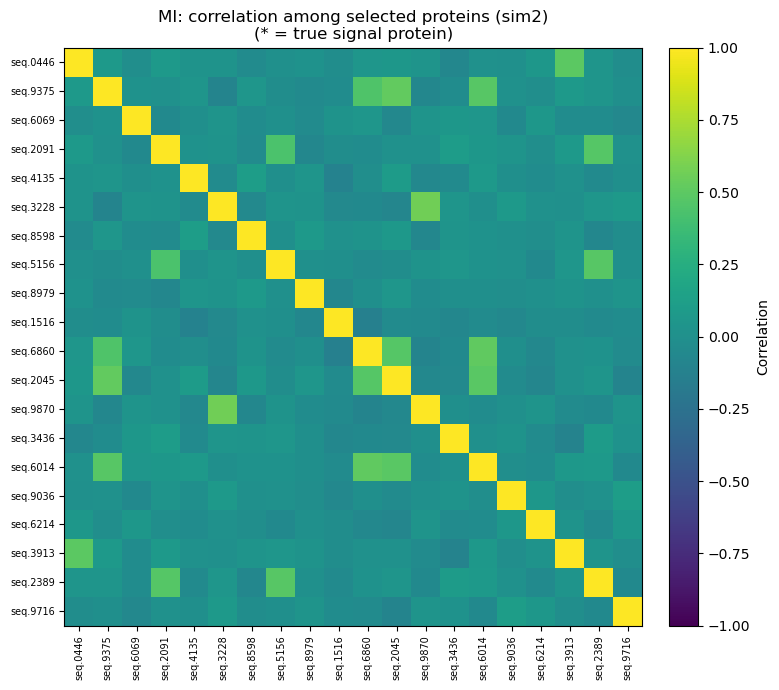

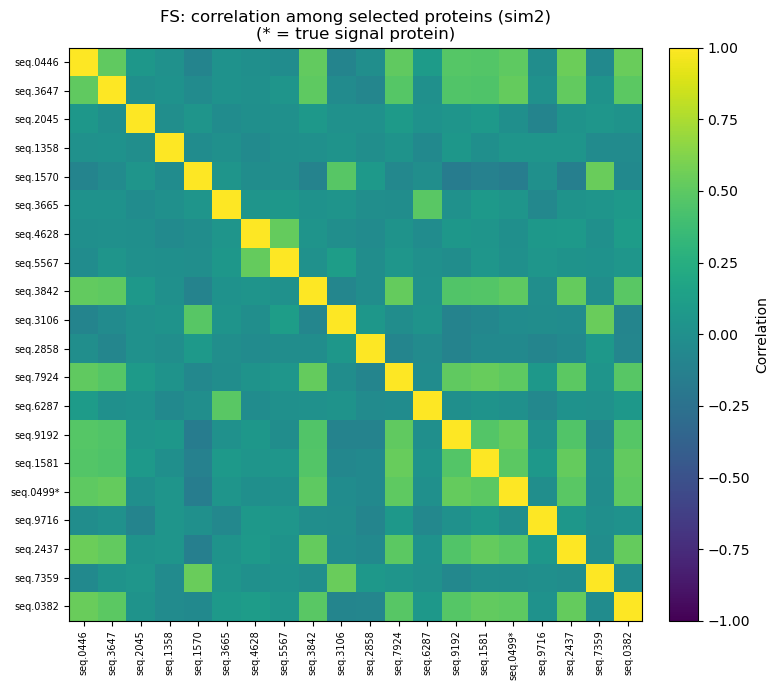

In [48]:
# Compare correlation heatmaps to sim2 10 000 proteins
corr_heatmap(simdata2, truth2, rank_t2, "t-test: correlation among selected proteins (sim2)", k=20)
corr_heatmap(simdata2, truth2, rank_m2, "MI: correlation among selected proteins (sim2)", k=20)
corr_heatmap(simdata2, truth2, rank_f2, "FS: correlation among selected proteins (sim2)", k=20)

# Riktiga datan

/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_51993/3306802087.py:13: DtypeWarning: Columns (10818,10820) have mixed types. Specify dtype option on import or set low_memory=False.
  realdata = pd.read_csv(realdata_path)


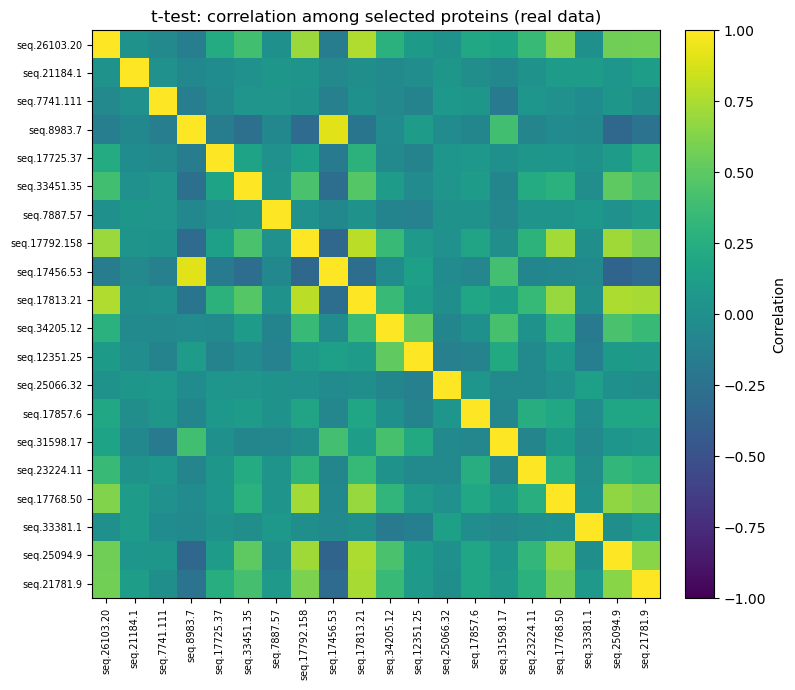

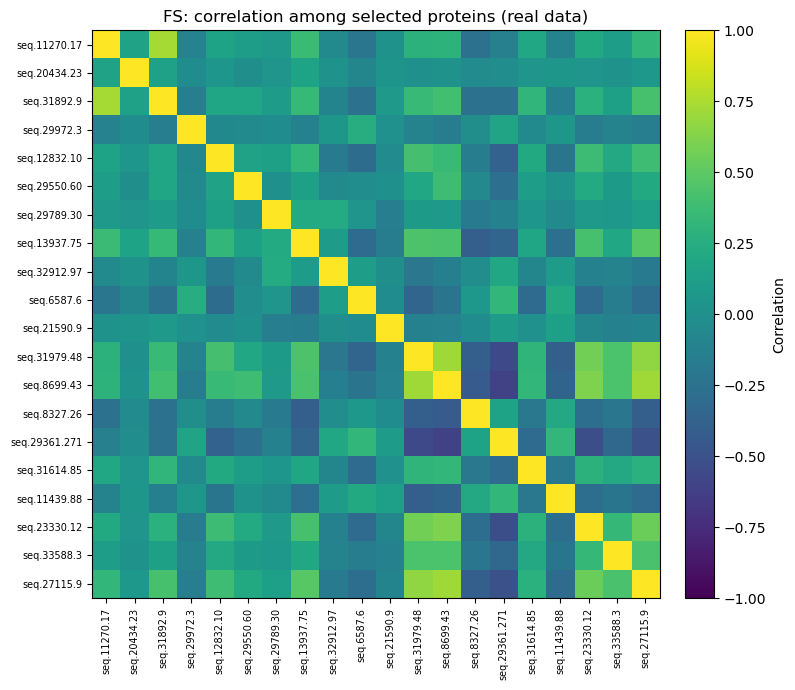

t-test: {'mean_corr': 0.09814115135727168, 'mean_abs_corr': 0.1718433660246533, 'median_corr': 0.029879032531324866, 'n_pairs': 190}
FS: {'mean_corr': 0.035506743269652856, 'mean_abs_corr': 0.20708619932602382, 'median_corr': 0.02596707269774421, 'n_pairs': 190}


In [49]:
real_dir = Path("../data/processed")

# ändra dessa om filnamnen skiljer sig
realdata_path = real_dir / "filtered_data.csv"

ttest_path = Path("../results/ttest/filtered_data/selected_features_k20.csv")
#mi_path    = Path("../results/sim_uni/selected_features_k20.csv")
fs_path    = Path("../results/fs/selected_features_n_features20.csv")

# -------------------------
# Load
# -------------------------
realdata = pd.read_csv(realdata_path)
features_ttest_real = pd.read_csv(ttest_path)
#features_mi_real    = pd.read_csv(mi_path)
features_fs_real    = pd.read_csv(fs_path)

# -------------------------
# Helper
# -------------------------
def _find_feature_col(df: pd.DataFrame) -> str:
    for c in ["protein", "Protein", "feature", "Feature", "selected_feature", "features"]:
        if c in df.columns:
            return c
    return df.columns[0]

def corr_heatmap_real(data, selected_list, title, k=20):
    feats = [p for p in selected_list if p in data.columns][:k]

    if len(feats) < 2:
        print(f"Too few matching features for {title}")
        return

    X = data[feats].apply(pd.to_numeric, errors="coerce").to_numpy()
    C = np.corrcoef(X, rowvar=False)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(C, vmin=-1, vmax=1)

    ax.set_title(title)
    ax.set_xticks(range(len(feats)))
    ax.set_yticks(range(len(feats)))
    ax.set_xticklabels(feats, rotation=90, fontsize=7)
    ax.set_yticklabels(feats, fontsize=7)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation")

    plt.tight_layout()
    plt.show()

def mean_corr(data, selected_list, k=20):

    feats = [p for p in selected_list if p in data.columns][:k]

    if len(feats) < 2:
        print("Too few features")
        return None

    X = data[feats].apply(pd.to_numeric, errors="coerce").to_numpy()
    C = np.corrcoef(X, rowvar=False)

    # upper triangle without diagonal
    iu = np.triu_indices_from(C, k=1)
    corr_vals = C[iu]

    mean_corr = np.mean(corr_vals)
    mean_abs_corr = np.mean(np.abs(corr_vals))
    median_corr = np.median(corr_vals)

    return {
        "mean_corr": mean_corr,
        "mean_abs_corr": mean_abs_corr,
        "median_corr": median_corr,
        "n_pairs": len(corr_vals)
    }
# -------------------------
# Feature lists
# -------------------------
rank_t_real = features_ttest_real[_find_feature_col(features_ttest_real)].astype(str).tolist()
#rank_m_real = features_mi_real[_find_feature_col(features_mi_real)].astype(str).tolist()
rank_f_real = features_fs_real[_find_feature_col(features_fs_real)].astype(str).tolist()

# -------------------------
# Heatmaps
# -------------------------
corr_heatmap_real(realdata, rank_t_real, "t-test: correlation among selected proteins (real data)", k=20)
#corr_heatmap_real(realdata, rank_m_real, "MI: correlation among selected proteins (real data)", k=20)
corr_heatmap_real(realdata, rank_f_real, "FS: correlation among selected proteins (real data)", k=20)

stats_t = mean_corr(realdata, rank_t_real, k=20)
stats_f = mean_corr(realdata, rank_f_real, k=20)

print("t-test:", stats_t)
print("FS:", stats_f)


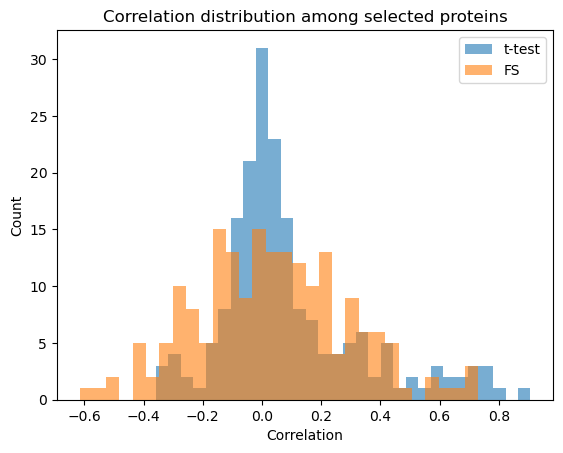

In [50]:
def corr_distribution(data, selected_list, label, k=20):

    feats = [p for p in selected_list if p in data.columns][:k]

    X = data[feats].apply(pd.to_numeric, errors="coerce").to_numpy()
    C = np.corrcoef(X, rowvar=False)

    iu = np.triu_indices_from(C, k=1)
    vals = C[iu]

    plt.hist(vals, bins=30, alpha=0.6, label=label)

corr_distribution(realdata, rank_t_real, "t-test")
corr_distribution(realdata, rank_f_real, "FS")

plt.xlabel("Correlation")
plt.ylabel("Count")
plt.title("Correlation distribution among selected proteins")
plt.legend()
plt.show()

In [51]:
# Kolla överlapp mellan vilka proteiner de hittar

# top-k features
k = 20

set_t = set(rank_t_real[:k])
set_f = set(rank_f_real[:k])

overlap = set_t & set_f
only_t = set_t - set_f
only_f = set_f - set_t

print("=== Feature overlap (top 20) ===\n")

print(f"t-test features: {len(set_t)}")
print(f"FS features: {len(set_f)}")

print(f"\nOverlap: {len(overlap)} proteins")
print(sorted(overlap))

print(f"\nOnly t-test: {len(only_t)}")
print(sorted(only_t))

print(f"\nOnly FS: {len(only_f)}")
print(sorted(only_f))

# Jaccard similarity
jaccard = len(overlap) / len(set_t | set_f)
print(f"\nJaccard similarity: {jaccard:.3f}")


=== Feature overlap (top 20) ===

t-test features: 20
FS features: 20

Overlap: 0 proteins
[]

Only t-test: 20
['seq.12351.25', 'seq.17456.53', 'seq.17725.37', 'seq.17768.50', 'seq.17792.158', 'seq.17813.21', 'seq.17857.6', 'seq.21184.1', 'seq.21781.9', 'seq.23224.11', 'seq.25066.32', 'seq.25094.9', 'seq.26103.20', 'seq.31598.17', 'seq.33381.1', 'seq.33451.35', 'seq.34205.12', 'seq.7741.111', 'seq.7887.57', 'seq.8983.7']

Only FS: 20
['seq.11270.17', 'seq.11439.88', 'seq.12832.10', 'seq.13937.75', 'seq.20434.23', 'seq.21590.9', 'seq.23330.12', 'seq.27115.9', 'seq.29361.271', 'seq.29550.60', 'seq.29789.30', 'seq.29972.3', 'seq.31614.85', 'seq.31892.9', 'seq.31979.48', 'seq.32912.97', 'seq.33588.3', 'seq.6587.6', 'seq.8327.26', 'seq.8699.43']

Jaccard similarity: 0.000
